EMPLOYEE ATTRITION ANALYSIS - PYTHON(PANDAS AND  MATPLOTLIB)

BUSINESS PROBLEM 

Which department and recuitment source have the highest voluntary attrition , and is it driven by low engagement/satisfaction ot by pay - so HR can prioritize where to focus retention efforts first ? 

EXECUTIVE SUMMARY

- **Operations has the highest attrition (37%)** — nearly double Marketing's rate (20%).
- **Employee Referral and Indeed hires churn the most** (32.9% and 30.3%), despite Referral being the most "trusted" channel on paper.
- **Job satisfaction, not salary, is the stronger attrition signal** — leavers report satisfaction of 2.53/5 vs 3.23/5 for stayers, while salary gap between the two groups is small (~₹4,400/month).
- **Top exit reasons are growth-related**, not pay-related: "No Growth" (27) and "Better Opportunity" (21) combined outnumber "Higher Salary Elsewhere" (11) by nearly 3:1.
- **Recommendation:** HR should prioritize a retention review for Operations and re-evaluate the Employee Referral pipeline (screening/expectations mismatch), and invest in internal growth paths rather than assuming pay is the main lever.


IMPORT AND LOAD 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Dell\Downloads\employee_attrition_data.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             500 non-null    object 
 1   FullName               500 non-null    object 
 2   Gender                 500 non-null    object 
 3   Age                    500 non-null    int64  
 4   DateOfBirth            500 non-null    object 
 5   MaritalStatus          500 non-null    object 
 6   Education              500 non-null    object 
 7   City                   500 non-null    object 
 8   Department             500 non-null    object 
 9   Position               500 non-null    object 
 10  ManagerName            500 non-null    object 
 11  RecruitmentSource      500 non-null    object 
 12  DateOfJoining          500 non-null    object 
 13  DateOfExit             129 non-null    object 
 14  TenureYears            500 non-null    float64
 15  Monthl

In [3]:
df.describe()

,Age,TenureYears,MonthlySalary,EngagementScore,JobSatisfaction,Absences,DaysLateInMonth,TrainingHoursLastYear,ProjectsCompleted,Attrition
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,36.524000,5.609800,73974.808000,3.244320,3.05200,12.810000,4.33200,38.574000,5.992000,0.258000
std,8.952414,2.670391,22908.259147,0.991866,1.43297,7.512308,2.53666,23.575499,3.748605,0.437972
min,22.000000,1.000000,38139.000000,1.520000,1.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,29.000000,3.300000,54514.000000,2.377500,2.00000,6.000000,2.00000,17.000000,3.000000,0.000000
50%,36.000000,5.700000,71981.000000,3.245000,3.00000,13.000000,4.00000,39.000000,6.000000,0.000000
75%,44.000000,8.000000,87019.500000,4.080000,4.00000,20.000000,7.00000,58.000000,9.000000,1.000000
max,52.000000,10.000000,141683.000000,4.990000,5.00000,25.000000,8.00000,80.000000,12.000000,1.000000


In [4]:
df.sample

<bound method NDFrame.sample of     EmployeeID        FullName  Gender  Age DateOfBirth MaritalStatus  \
0      EMP1001   Vikram Pillai    Male   35  1989-06-24      Divorced   
1      EMP1002      Amit Kumar    Male   24  2000-11-11        Single   
2      EMP1003    Anita Pillai  Female   40  1984-05-13      Divorced   
3      EMP1004    Nikhil Desai    Male   29  1995-04-05      Divorced   
4      EMP1005     Rajesh Iyer    Male   27  1997-12-17      Divorced   
..         ...             ...     ...  ...         ...           ...   
495    EMP1496       Amit Iyer    Male   45  1979-05-06        Single   
496    EMP1497     Divya Kumar  Female   33  1991-03-16        Single   
497    EMP1498  Aishwarya Nair  Female   24  2000-03-03        Single   
498    EMP1499     Deepak Iyer    Male   46  1978-02-09        Single   
499    EMP1500     Simran Iyer  Female   23  2001-09-23        Single   

    Education       City  Department                Position  ...  \
0      B.Tech    Kolka

In [5]:
df.isna().sum()

EmployeeID                 0
FullName                   0
Gender                     0
Age                        0
DateOfBirth                0
MaritalStatus              0
Education                  0
City                       0
Department                 0
Position                   0
ManagerName                0
RecruitmentSource          0
DateOfJoining              0
DateOfExit               371
TenureYears                0
MonthlySalary              0
PerformanceRating          0
EngagementScore            0
JobSatisfaction            0
Absences                   0
DaysLateInMonth            0
TrainingHoursLastYear      0
ProjectsCompleted          0
EmploymentStatus           0
ExitReason               371
Attrition                  0
dtype: int64

DATA CLEANING

- `DateOfBirth`, `DateOfJoining`, `DateOfExit` need to be parsed as real dates (currently strings)
- `Attrition` is already a clean 0/1 flag — confirm it matches `EmploymentStatus`
- Check for duplicate `EmployeeID`
- Check categorical columns for inconsistent casing/whitespace


In [6]:
df['DateOfBirth']=pd.to_datetime(df['DateOfBirth'],errors='coerce')

In [7]:
df['DateOfExit']=pd.to_datetime(df['DateOfExit'],errors='coerce')

In [8]:
df['DateOfJoining']=pd.to_datetime(df['DateOfJoining'],errors='coerce')

In [9]:
df['ExitReason'].fillna('Still employeed')

0        Still employeed
1        Still employeed
2      Work-Life Balance
3        Still employeed
4        Still employeed
             ...        
495            No Growth
496      Still employeed
497      Still employeed
498      Still employeed
499      Still employeed
Name: ExitReason, Length: 500, dtype: object

In [10]:
df['DateOfExit'].fillna('Still employeed')

0          Still employeed
1          Still employeed
2      2023-06-09 00:00:00
3          Still employeed
4          Still employeed
              ...         
495    2021-06-06 00:00:00
496        Still employeed
497        Still employeed
498        Still employeed
499        Still employeed
Name: DateOfExit, Length: 500, dtype: object

In [11]:
df.duplicated('EmployeeID').sum()

np.int64(0)

In [12]:
pd.crosstab(df['Attrition'],df['EmploymentStatus'])

EmploymentStatus,Active,Terminated,Voluntarily Resigned
Attrition,,,
0,371,0,0
1,0,53,76


FEATURE ENGINNERING

`TenureYears` is already provided, but we derive a couple of extra fields useful for the analysis:
- `AttritionLabel` — readable version of the 0/1 flag, for chart labels


In [13]:
df['AttritionLabel']=df['Attrition'].map({0:"stayed",1:"left"})

WHICH DEPARTMENT HAS THE HIGHEST ATTRITION?

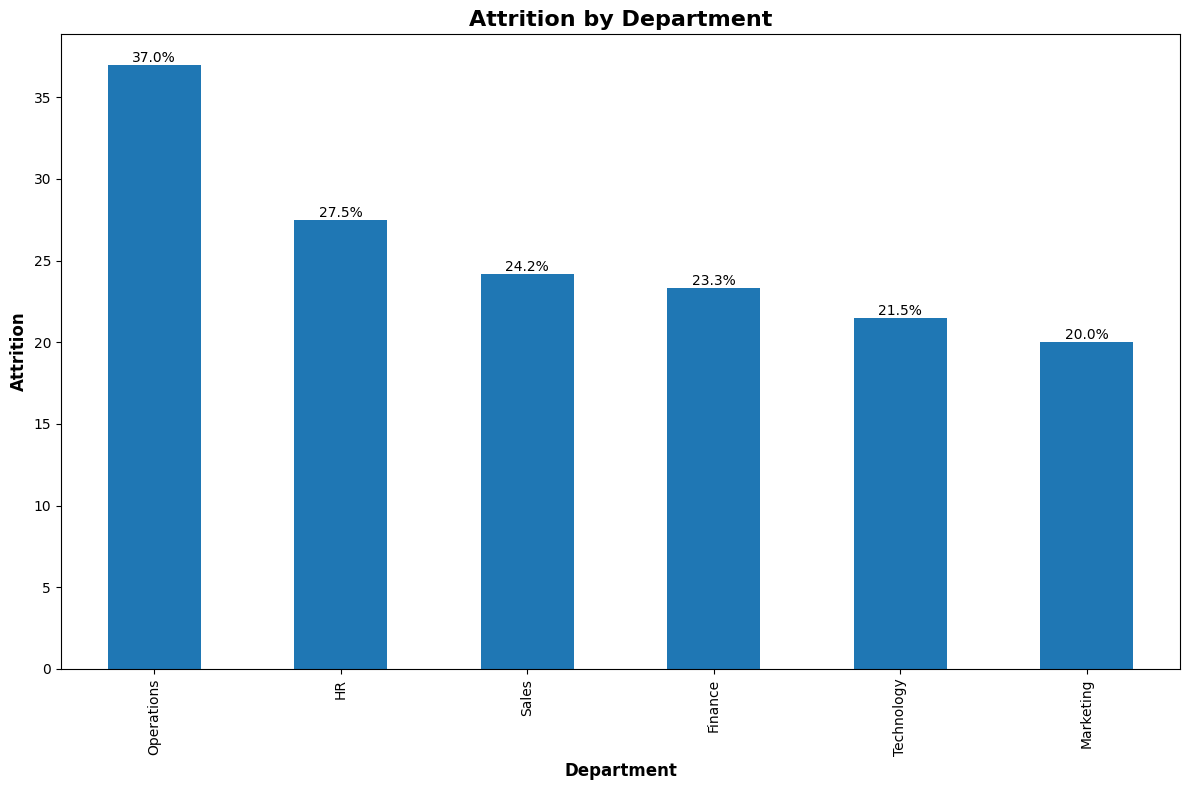

In [14]:
fig,ax=plt.subplots(figsize=(12,8))
df.groupby('Department')['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).plot(kind='bar',
)
ax.set_title('Attrition by Department',fontweight='bold',fontsize=16)
ax.set_xlabel('Department',fontweight='bold',fontsize=12)
ax.set_ylabel('Attrition',fontweight='bold',fontsize=12)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.savefig('attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

**Finding:** Operations has the highest attrition at **37%** — nearly 2x Marketing's 20%, and well above the company average (~25.8%). This is the single biggest lever HR has for reducing overall attrition: fixing Operations alone would move the needle more than any other department.

DOES ENGAGMENET OR SATISFACTION PREDICT WHO LEAVES ? 

In [15]:
metrices= df.groupby('AttritionLabel')[['EngagementScore','JobSatisfaction','MonthlySalary']].mean().round(2)
print(metrices)

                EngagementScore  JobSatisfaction  MonthlySalary
AttritionLabel                                                 
left                       3.02             2.53       70700.52
stayed                     3.32             3.23       75113.31


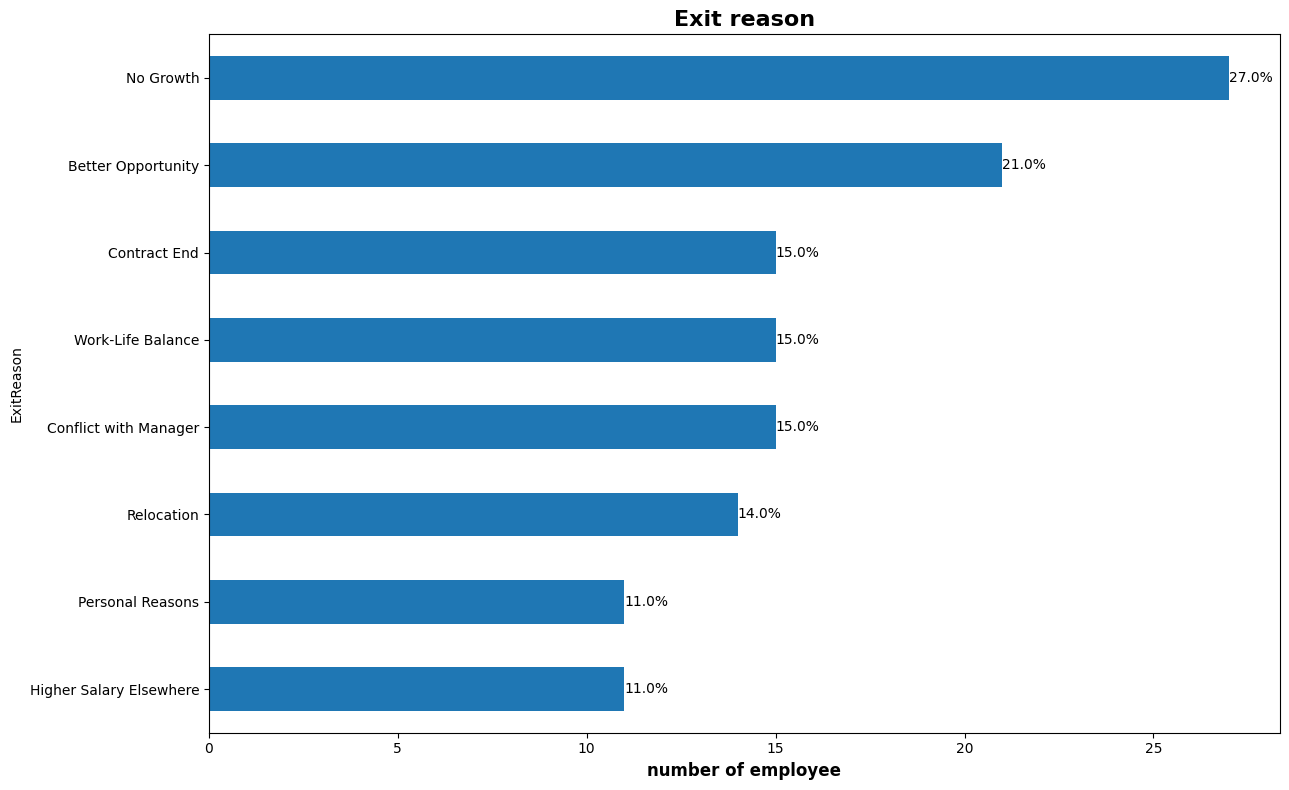

In [16]:
fig,ax=plt.subplots(figsize=(13,8))
df.groupby('ExitReason')['EmployeeID'].count().sort_values(ascending=True).plot(kind='barh')
ax.set_title('Exit reason',fontweight='bold',fontsize=16)
ax.set_xlabel('number of employee',fontweight='bold',fontsize=12)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.savefig('count of emp by exit reason.png',dpi=150,bbox_inches='tight')
plt.tight_layout()
plt.show()

**Finding:** Growth-related reasons (**"No Growth" + "Better Opportunity" = 48 exits**) dominate over pay-related reasons (**"Higher Salary Elsewhere" = 11 exits**). This reframes the retention conversation from "pay people more" to "give people a visible path forward."

WHICH RECRUITMENT SOURCES PRODUCES EMPLOYEES WHO STAYS ? 

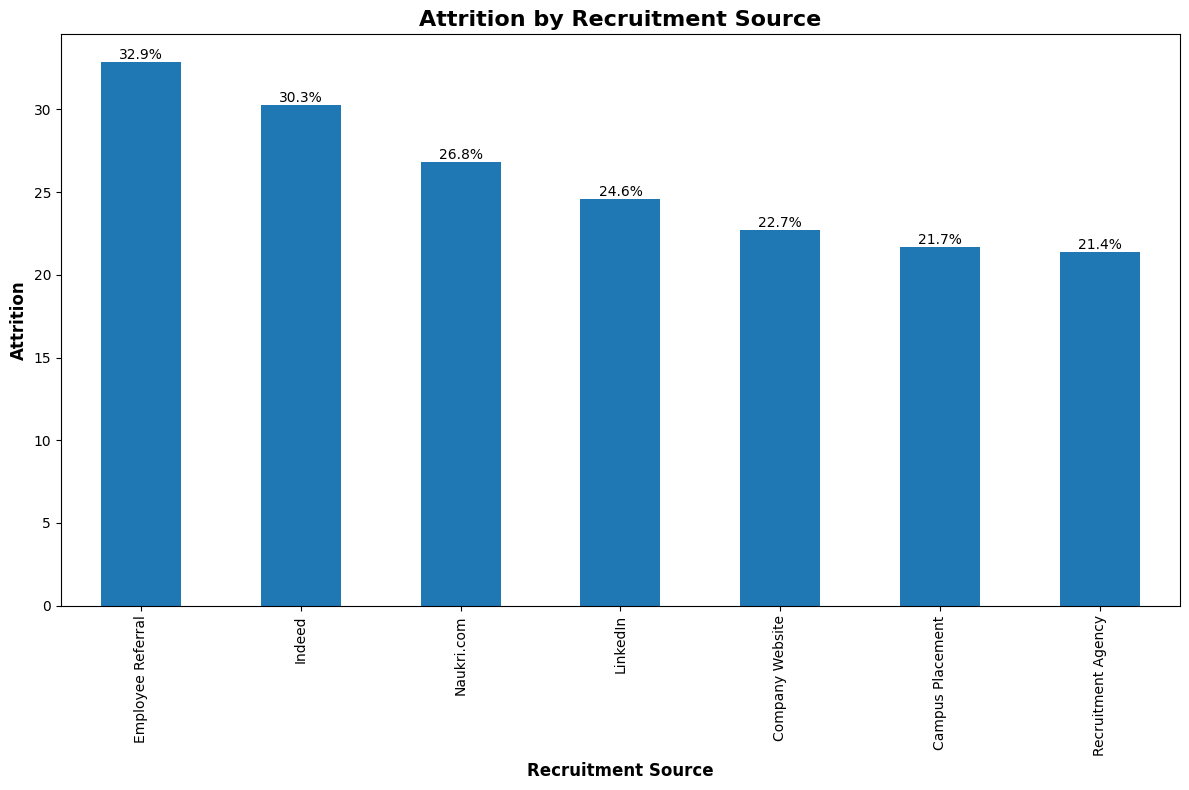

In [17]:
fig,ax=plt.subplots(figsize=(12,8))
df.groupby('RecruitmentSource')['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).plot(
    kind='bar')
ax.set_title('Attrition by Recruitment Source',fontweight='bold',fontsize=16)
ax.set_xlabel('Recruitment Source',fontweight='bold',fontsize=12)
ax.set_ylabel('Attrition',fontweight='bold',fontsize=12)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.savefig('attrition by recruitment source.png',dpi=150,bbox_inches='tight')
plt.tight_layout()
plt.show()

**Finding (the surprising one):** **Employee Referral has the highest attrition (32.9%)** — higher than Indeed, and far higher than Recruitment Agency (21.4%, the lowest). This goes against the common assumption that referrals are always the "safest" hiring channel. Combined with Business Question 2, this suggests referred hires may be joining with growth expectations set informally by the referring employee, which the company isn't meeting.

SUMMARY DASHBOARD

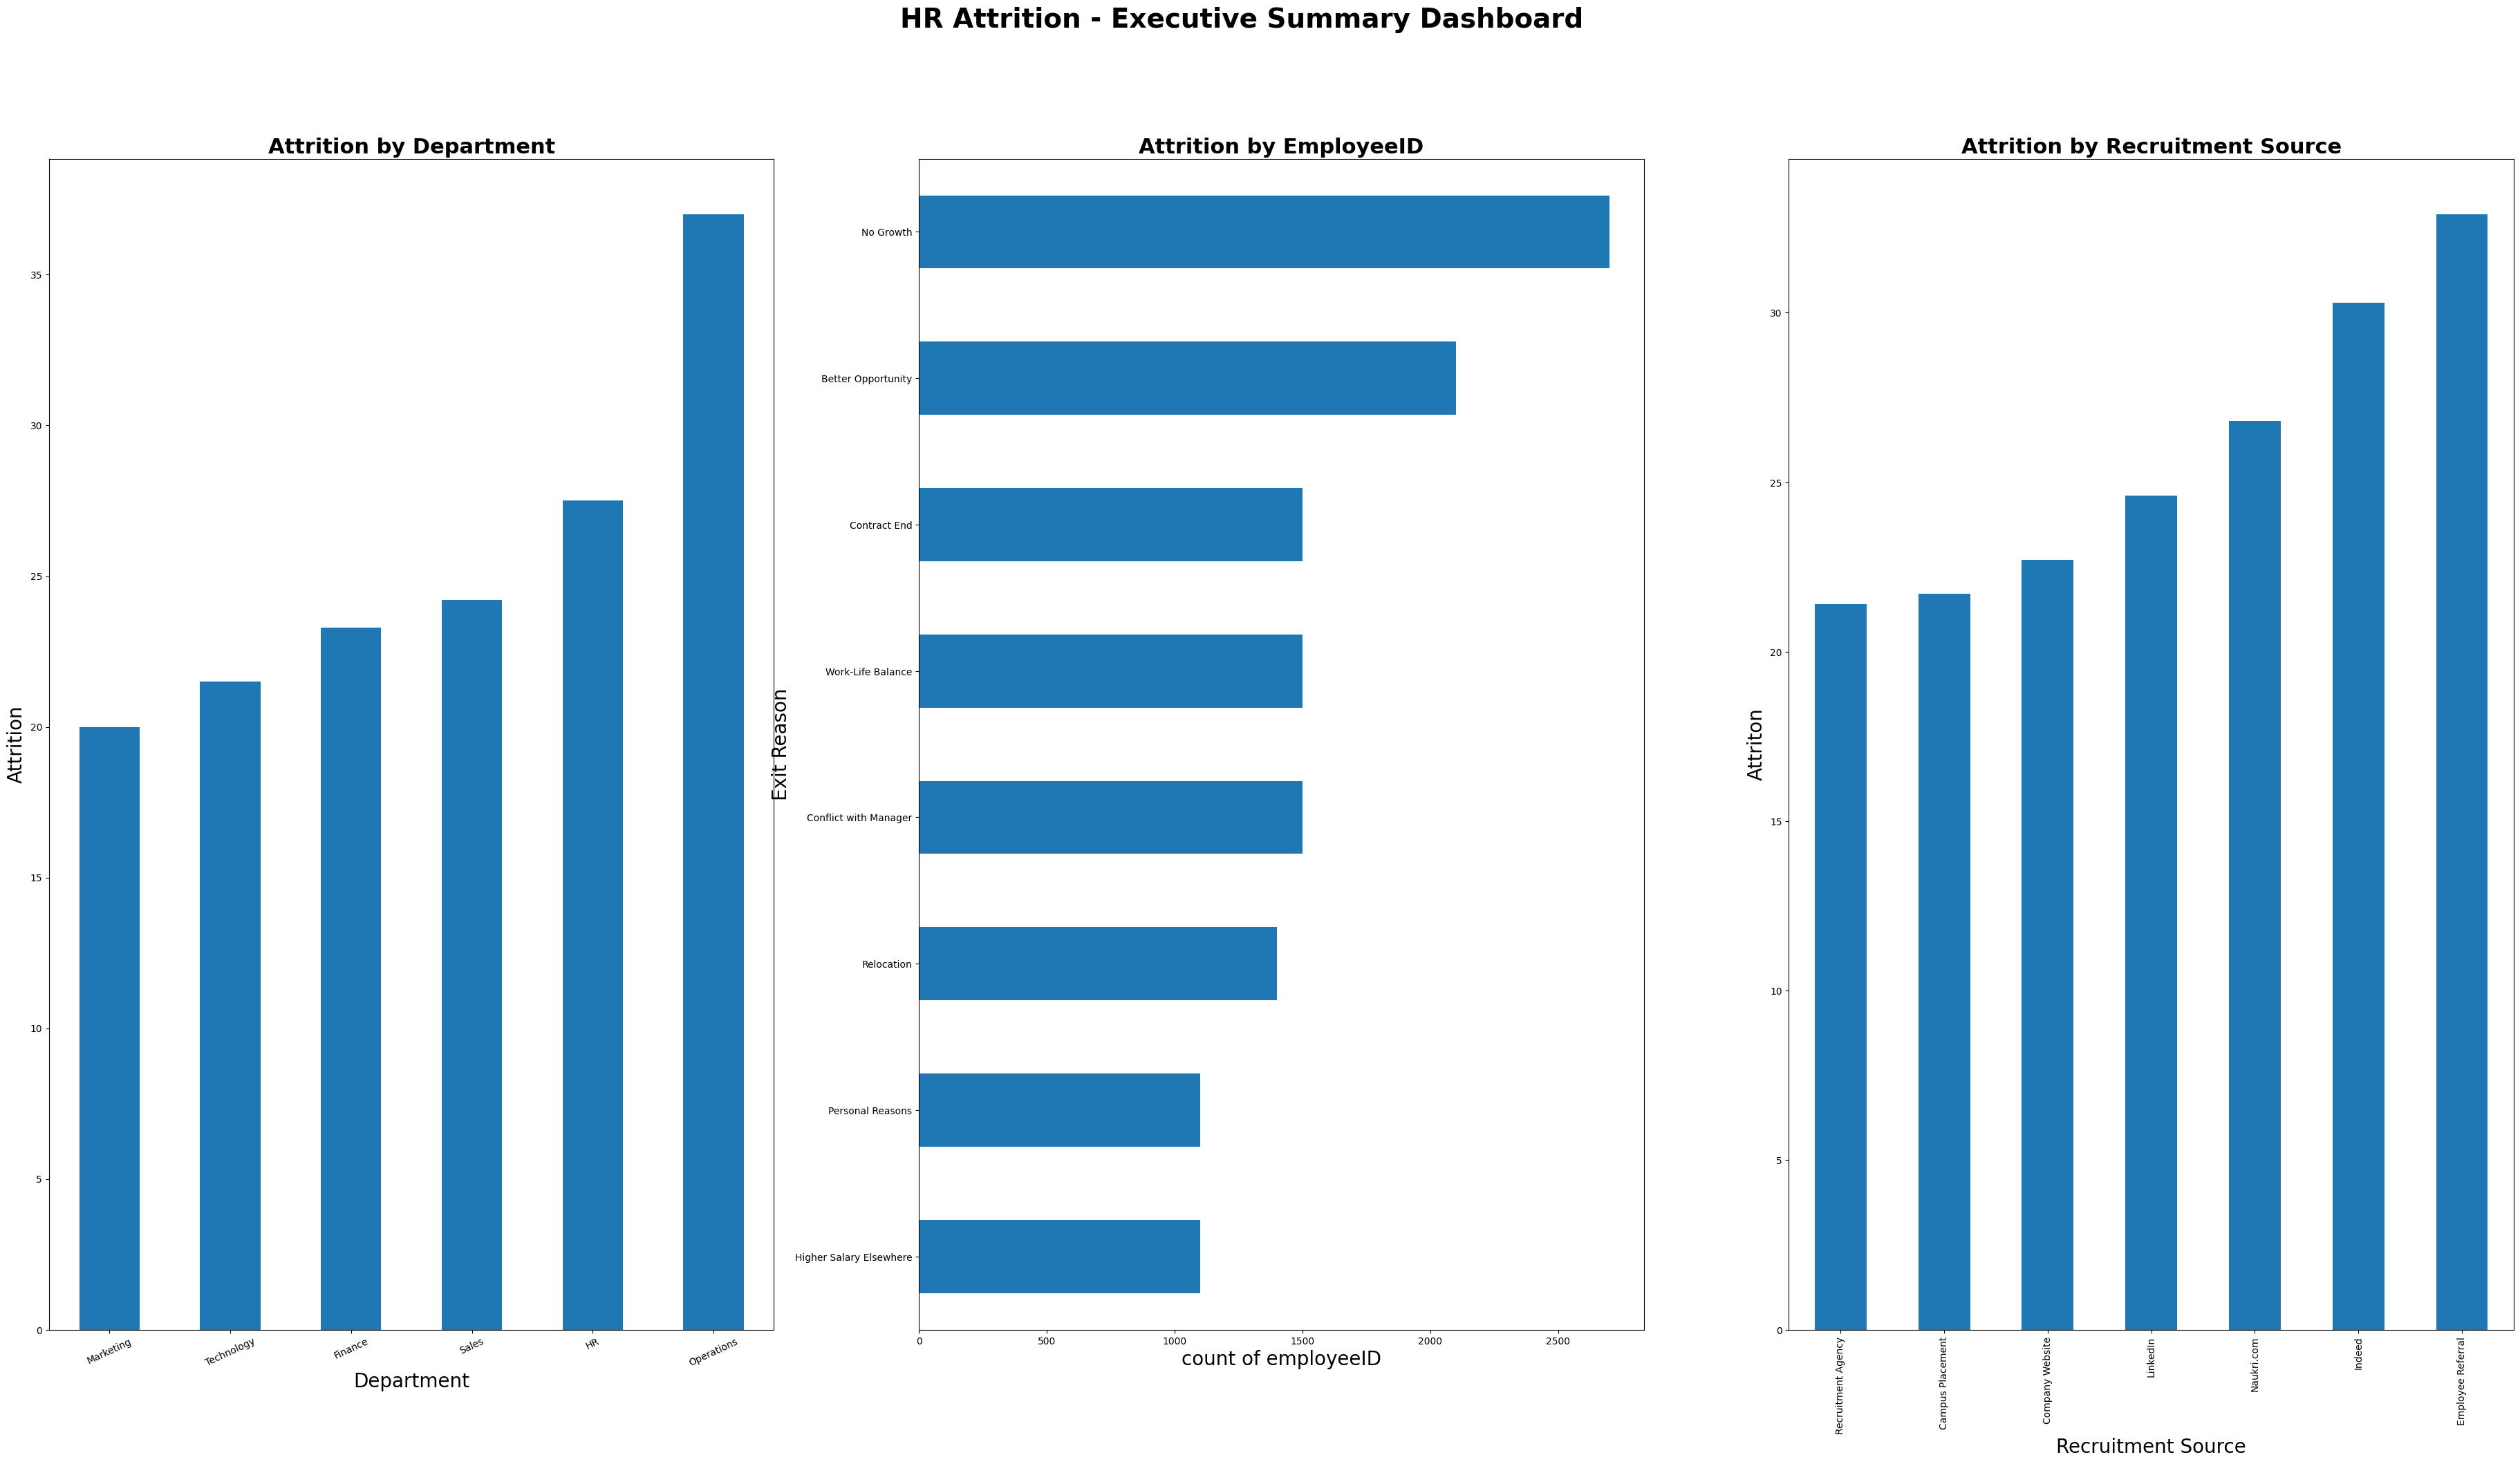

In [18]:
fig , axes = plt.subplots(1,3,figsize=(46,22))
plt.suptitle('HR Attrition - Executive Summary Dashboard',fontweight='bold',fontsize=28)
df.groupby('Department')['Attrition'].mean().mul(100).round(1).sort_values(ascending=True).plot(kind='bar',ax=axes[0])
axes[0].set_title('Attrition by Department',fontweight='bold',fontsize=22)
axes[0].set_xlabel('Department',fontsize=20)
axes[0].set_ylabel('Attrition',fontsize=20)
axes[0].tick_params(axis='x', rotation=25)
df.groupby('ExitReason')['EmployeeID'].count().mul(100).round(1).sort_values(ascending=True).plot(kind='barh',ax=axes[1])
axes[1].set_title('Attrition by EmployeeID',fontweight='bold',fontsize=22)
axes[1].set_xlabel('count of employeeID',fontsize=20)
axes[1].set_ylabel('Exit Reason',fontsize=20)
df.groupby('RecruitmentSource')['Attrition'].mean().mul(100).round(1).sort_values(ascending=True).plot(kind='bar',ax=axes[2])
axes[2].set_title('Attrition by Recruitment Source',fontweight='bold',fontsize=22)
axes[2].set_xlabel('Recruitment Source',fontsize=20)
axes[2].set_ylabel('Attriton',fontsize=20)
plt.savefig('dasboard',dpi=150,bbox_inches='tight')
plt.show()


BUSINESS RECOMMENDATION 

**For HR leadership:**

1. **Prioritize Operations for a retention review** — its 37% attrition is the single largest contributor to overall churn. Even bringing it down to the company average (~26%) would meaningfully cut total attrition.
2. **Audit the Employee Referral pipeline** — despite its reputation, it has the highest attrition of any source. Interview a sample of recently-referred leavers to check for expectation mismatches at hiring.
3. **Invest in visible growth paths, not just pay** — "No Growth" and "Better Opportunity" account for 48 of 129 exits (37%), nearly 3x the pay-related reasons. A structured internal mobility or promotion-visibility program is likely to have more impact than a salary bump.

